#Installs

In [ ]:
!pip install ultralytics
#!pip install faster-coco-eval
#!pip install tensordict
#!pip install torchrl
### Baidu's RT-DETR
# Load a COCO-pretrained RT-DETR-l model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.8 MB/s eta 0:00:00


# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#Parsing Loaded HomeObject Classes

In [ ]:
# #redo the ncs of the txt files
import os
import numpy as np
import pandas as pd
# #get the paths of each file
# # ignore "images/train", "images/val" because they are jpgs
root = "/content/drive/MyDrive/homeobjects-3K"
# for local in ["labels/train","labels/val"]:
#     path = os.path.join(root, local)
#     arr = np.array(sorted(os.listdir(path)))
#     #parse each text file, each is 5 columns with the class idx at the 1st column, ie 1 0.5383895 0.6073657 0.8408238 0.2634207
#     for p in arr:
#       fp = os.path.join(path, p)
#       df = pd.read_csv(fp, sep=" ", header=None) #splice
#       df = df[df[0] == 2] #eliminate everything that is not chair
#       #if the file does not contain chairs, delete, image does not need to be deleted due to how they treat background
#       if df.empty:
#         os.remove(fp)
#       else:
#         df[0] = 0 #remap class as zero
#         df.to_csv(fp, sep=" ", header=False, index=False)

In [ ]:
#Clean up jpgs
for local in [["images/train","labels/train"],["images/val","labels/val"]]:
    i = os.path.join(root, local[0])
    images = sorted(os.listdir(i))
    labels = {os.path.splitext(f)[0] for f in os.listdir(os.path.join(root, local[1]))}
    for p in images:
      if os.path.splitext(p)[0] not in labels:
        os.remove(os.path.join(i,p))

# Run training loop

yaml was edited into:

```

path: /content/drive/MyDrive/homeobjects-3K # dataset root dir
train: images/train # train images (relative to 'path') 2285 images
val: images/val # val images (relative to 'path') 404 images
test: # test images (relative to 'path')

nc: 1

# Classes
names:
  0: chair

In [ ]:
from ultralytics import RTDETR
from ultralytics import YOLO

In [ ]:
model = RTDETR("rtdetr-x.pt")

In [ ]:
os.chdir(root)

In [ ]:
model.train(
    data="/content/drive/MyDrive/homeobjects-3K/HomeObjects-3K.yaml",
    epochs=30,
    imgsz=640,
    batch=8, #cannot go higher, defaults to 8
    device=0,
    patience=20,
    amp=False,
    #lr0=0.001,
    #single_cls=True, #this removes the index check so don't turn on
    visualize=True,
    optimize=True
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/homeobjects-3K/HomeObjects-3K.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/homeobjects-3K/runs/detect/train2/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, 

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      12.9G     0.3639     0.6046     0.1497         26        640: 0% ──────────── 0/126  2.4sWARNING ⚠️ CUDA out of memory with batch=8. Reducing to batch=4 and retrying (1/3).
train: Fast image access ✅ (ping: 0.4±0.1 ms, read: 68.1±11.0 MB/s, size: 178.6 KB)
train: Scanning /content/drive/MyDrive/homeobjects-3K/labels/train.cache... 1002 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1002/1002 233.5Mit/s 0.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 1.2±1.0 ms, read: 21.0±9.0 MB/s, size: 137.8 KB)
val: Scanning /content/drive/MyDrive/homeobjects-3K/labels/val.cache... 154 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 154/154 5.7Mit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'm

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      8.78G     0.4167     0.6959     0.2221          6        640: 100% ━━━━━━━━━━━━ 251/251 1.1s/it 4:45
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.2s/it 11.7s
                   all        154        305      0.736      0.705       0.74      0.504

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       8/30      8.96G     0.4523     0.7146     0.2429          6        640: 100% ━━━━━━━━━━━━ 251/251 1.1s/it 4:39
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.2s/it 11.7s
                   all        154        305      0.635      0.692      0.693      0.448

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       9/30      8.97G     0.4439     0.7232     0.2445         22        640: 84% ━━━━━━━━━━── 210/251 1.0s/it 3:55<42.8s


KeyboardInterrupt: 


image 1/1 /content/drive/MyDrive/homeobjects-3K/images/val/living_room_453.jpg: 640x640 6 chairs, 122.5ms
Speed: 4.8ms preprocess, 122.5ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/homeobjects-3K/images/val/living_room_453.jpg: 640x448 4 chairs, 73.4ms
Speed: 2.8ms preprocess, 73.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 448)


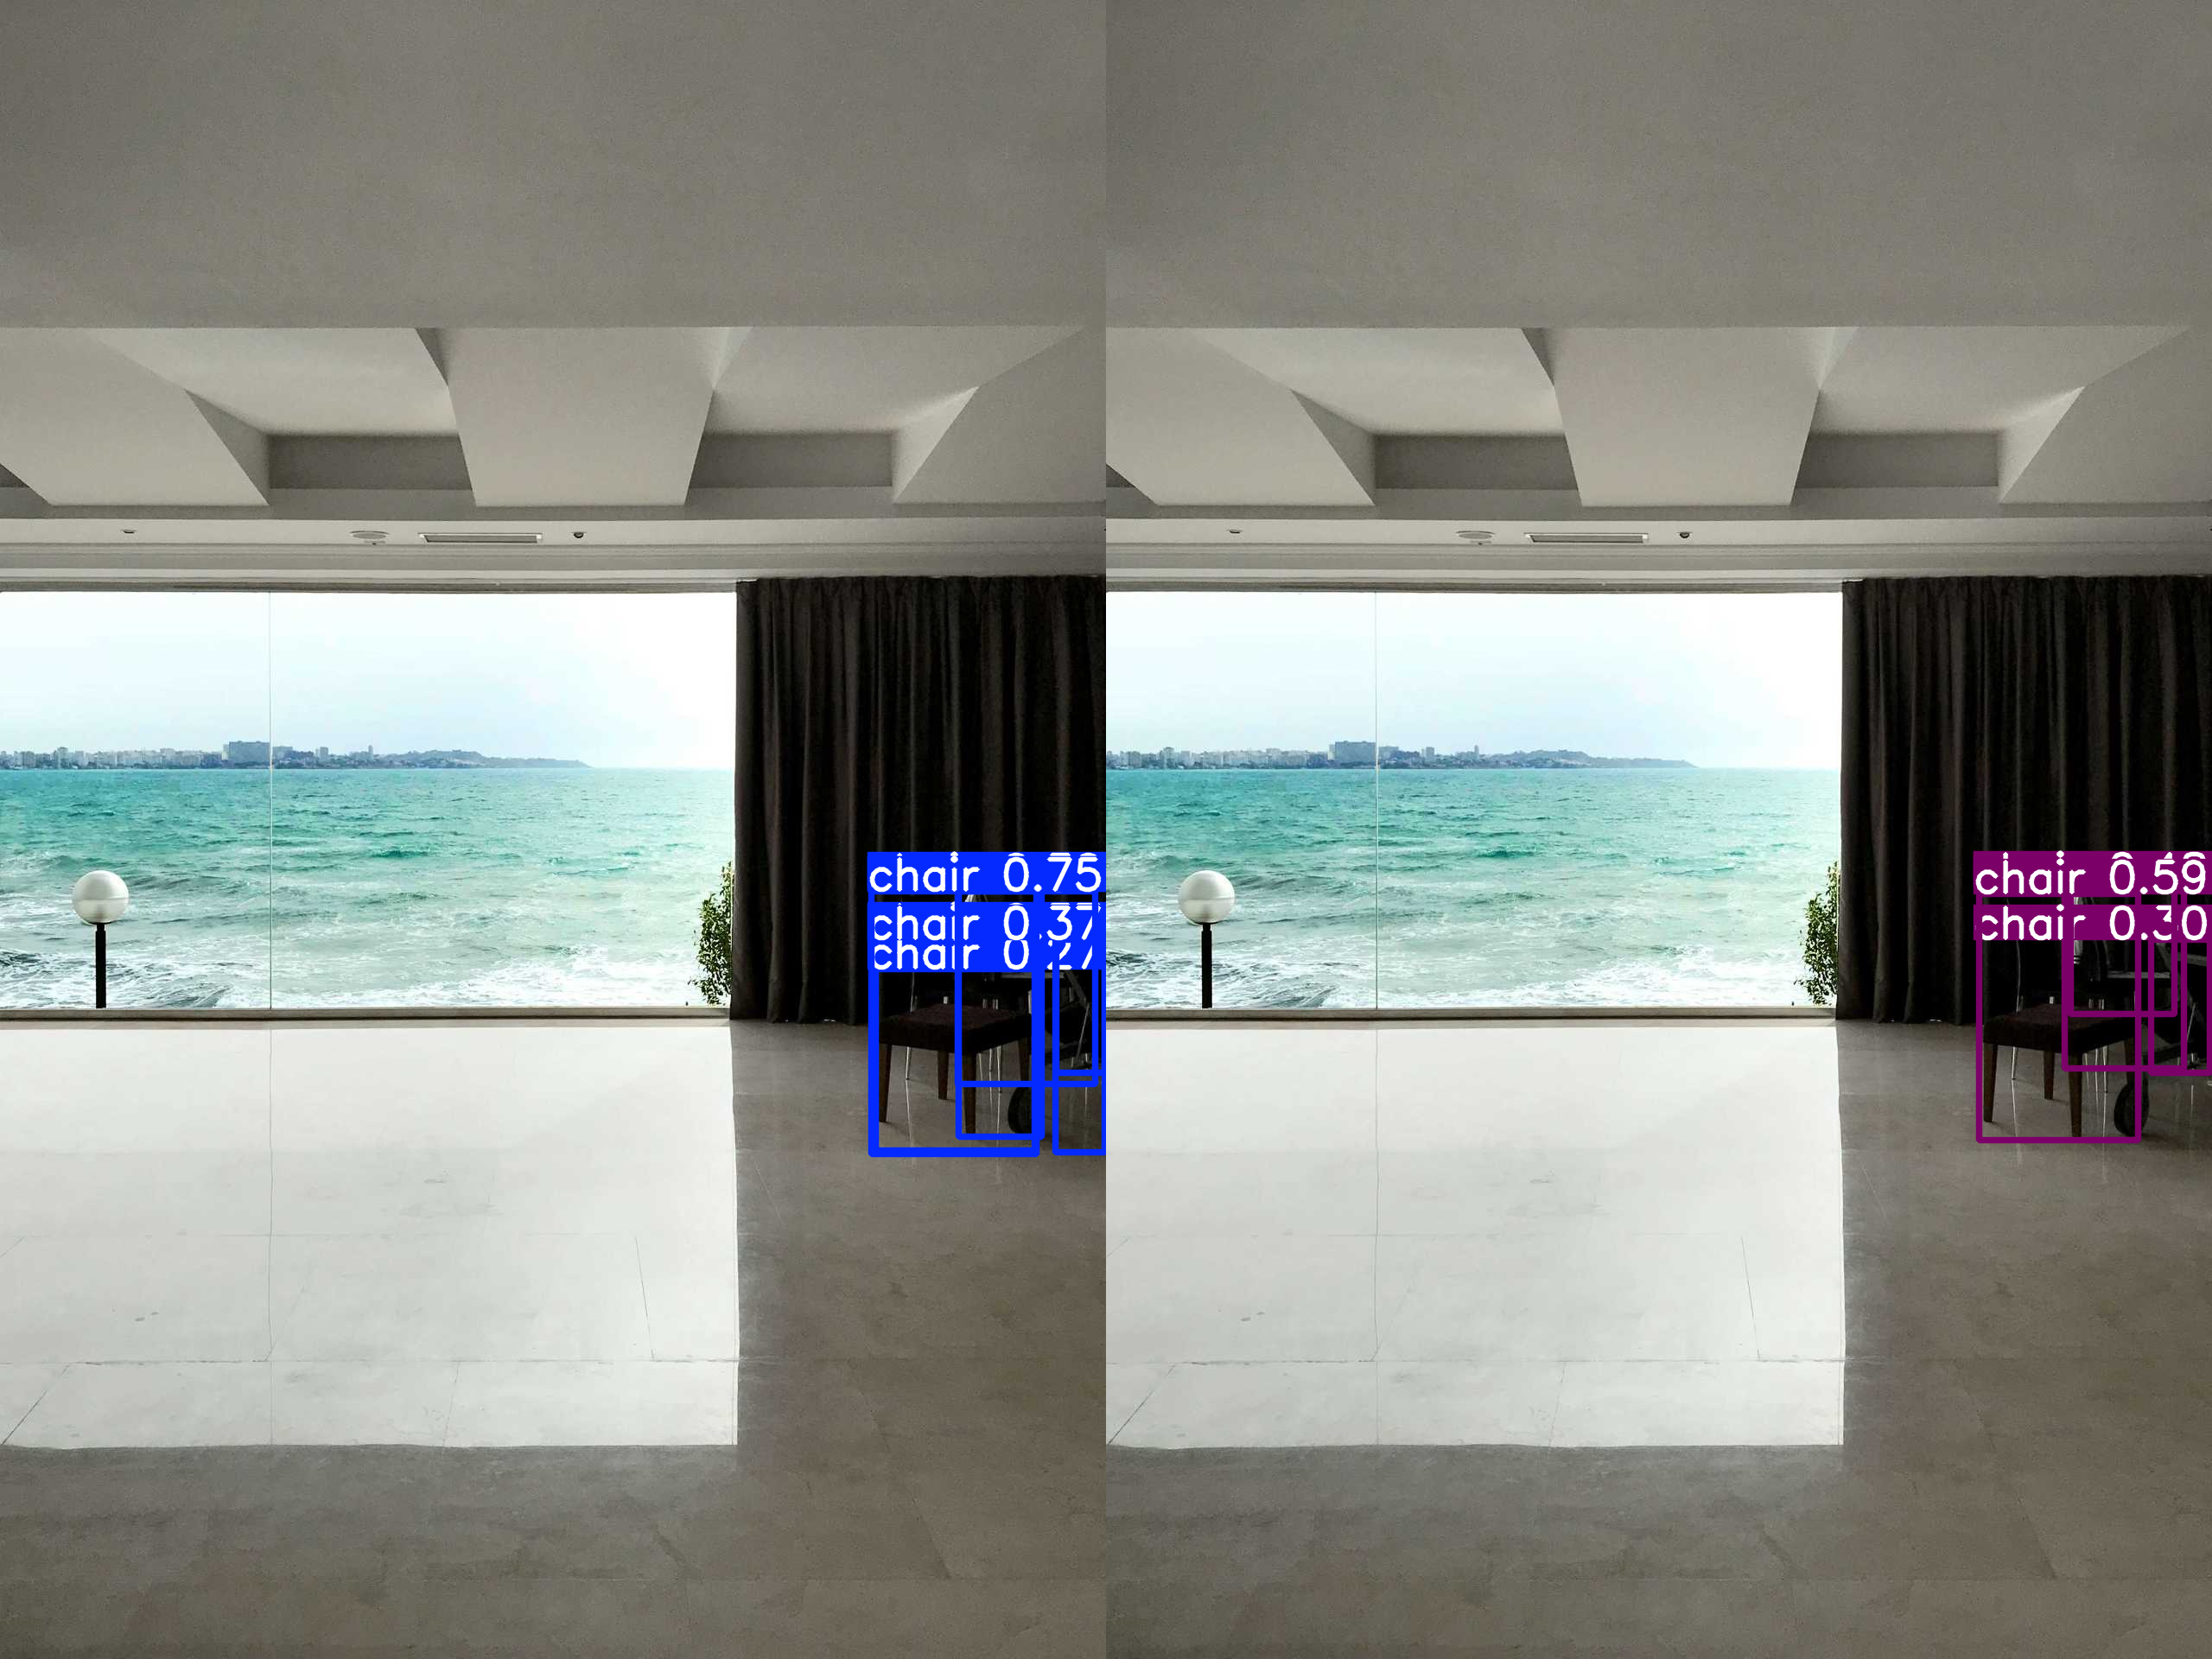

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [ ]:
from IPython.display import display
from PIL import Image
import random

#random img
leaf = random.choice(os.listdir("/content/drive/MyDrive/homeobjects-3K/images/val"))
img = os.path.join("/content/drive/MyDrive/homeobjects-3K/images/val", leaf)

# Run inference
results = model(img)
#original = RTDETR("rtdetr-x.pt")
#bresults = original(img, classes=[2])
original = YOLO("yolo26x.pt")
bresults = original(img, classes=[56])

# Side by side
ann1 = results[0].plot()
ann2 = bresults[0].plot()
side_by_side = np.concatenate((ann1, ann2), axis=1)
display(Image.fromarray(side_by_side[..., ::-1]))

# Class differential
def get_class_counts(r):
    if not r[0].boxes:
        return {}
    classes = r[0].boxes.cls.tolist()
    names = r[0].names
    return {names[int(c)]: classes.count(c) for c in set(classes)}

model_counts = get_class_counts(results)
original_counts = get_class_counts(bresults)
print(original.names)
all_classes = set(model_counts) | set(original_counts)
diff = {cls: model_counts.get(cls, 0) - original_counts.get(cls, 0) for cls in all_classes}
print(f"\n{'Class':<20} {'Model':>8} {'Original':>10} {'Diff':>6}")
print("-" * 46)
for cls in sorted(all_classes):
    m, o = model_counts.get(cls, 0), original_counts.get(cls, 0)
    print(f"{cls:<20} {m:>8} {o:>10} {m-o:>+6}")

In [ ]:
#save an image comparison you like
Image.fromarray(side_by_side[..., ::-1]).save(f"comparison_{leaf}")

In [ ]:
model.export(format="torchscript")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.30GHz)
rt-detr-x summary: 378 layers, 65,469,491 parameters, 0 gradients, 222.5 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/homeobjects-3K/runs/detect/train2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 5) (129.2 MB)

TorchScript: starting export with torch 2.10.0+cu128...
TorchScript: export success ✅ 12.6s, saved as '/content/drive/MyDrive/homeobjects-3K/runs/detect/train2/weights/best.torchscript' (251.1 MB)

Export complete (17.7s)
Results saved to /content/drive/MyDrive/homeobjects-3K/runs/detect/train2/weights
Predict:         yolo predict task=detect model=/content/drive/MyDrive/homeobjects-3K/runs/detect/train2/weights/best.torchscript imgsz=640 
Validate:        yolo val task=detect model=/content/drive/MyDrive/homeobjects-3K/runs/detect/train2/weights/best.torchscript imgsz=640 data=/content/drive/MyDrive/homeobjects-3K/HomeObjects-3K.yaml  
Visual

'/content/drive/MyDrive/homeobjects-3K/runs/detect/train2/weights/best.torchscript'

In [ ]:
print(os.listdir("content/drive/MyDrive/homeobjects-3K/images/val")[0])

In [ ]:
#do not run unless needed
model = RTDETR("/content/drive/MyDrive/homeobjects-3K/runs/detect/train2/weights/last.pt")  # load a partially trained model

# Resume training
results = model.train(resume=True)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/homeobjects-3K/HomeObjects-3K.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/homeobjects-3K/runs/detect/train2/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train22, nbs=64, nms=False,

AssertionError: /content/drive/MyDrive/homeobjects-3K/runs/detect/train2/weights/last.pt training to 20 epochs is finished, nothing to resume.
Start a new training without resuming, i.e. 'yolo train model=/content/drive/MyDrive/homeobjects-3K/runs/detect/train2/weights/last.pt'